Undergraduate Research Project - XAI Framework for Healthcare Fraud Detection

Parsa Rassekhi - 2026



Data Preprocessing

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('fraud.csv' , encoding = 'utf-8')
print(df.columns.tolist())


['个人编码', '一天去两家医院的天数', '就诊的月数', '月就诊天数_MAX', '月就诊天数_AVG', '月就诊医院数_MAX', '月就诊医院数_AVG', '就诊次数_SUM', '月就诊次数_MAX', '月就诊次数_AVG', '月统筹金额_MAX', '月统筹金额_AVG', '月药品金额_MAX', '月药品金额_AVG', '医院_就诊天数_MAX', '医院_就诊天数_AVG', '医院_统筹金_MAX', '医院_统筹金_AVG', '医院_药品_MAX', '医院_药品_AVG', '医院编码_NN', '顺序号_NN', '交易时间DD_NN', '交易时间YYYY_NN', '交易时间YYYYMM_NN', '住院天数_SUM', '个人账户金额_SUM', '统筹支付金额_SUM', 'ALL_SUM', '可用账户报销金额_SUM', '药品费发生金额_SUM', '药品费自费金额_SUM', '药品费申报金额_SUM', '贵重药品发生金额_SUM', '中成药费发生金额_SUM', '中草药费发生金额_SUM', '检查费发生金额_SUM', '检查费自费金额_SUM', '检查费申报金额_SUM', '贵重检查费金额_SUM', '治疗费发生金额_SUM', '治疗费自费金额_SUM', '治疗费申报金额_SUM', '手术费发生金额_SUM', '手术费自费金额_SUM', '手术费申报金额_SUM', '床位费发生金额_SUM', '床位费申报金额_SUM', '医用材料发生金额_SUM', '高价材料发生金额_SUM', '医用材料费自费金额_SUM', '成分输血申报金额_SUM', '其它发生金额_SUM', '其它申报金额_SUM', '一次性医用材料申报金额_SUM', '起付线标准金额_MAX', '起付标准以上自负比例金额_SUM', '医疗救助个人按比例负担金额_SUM', '最高限额以上金额_SUM', '基本统筹基金支付金额_SUM', '公务员医疗补助基金支付金额_SUM', '城乡救助补助金额_SUM', '基本个人账户支付_SUM', '非账户支付金额_SUM', '本次审批金额_SUM', '补助审批金额_SUM', '医疗救助医院申请_SUM', '残疾军人补助_SUM', '民政救助补

In [68]:
column_mapping = {
    '个人编码': 'personal_code',
    '一天去两家医院的天数': 'days_two_hospitals_in_one_day',
    '就诊的月数': 'months_with_visits',
    '月就诊天数_MAX': 'monthly_visit_days_max',
    '月就诊天数_AVG': 'monthly_visit_days_avg',
    '月就诊医院数_MAX': 'monthly_hospital_count_max',
    '月就诊医院数_AVG': 'monthly_hospital_count_avg',
    '就诊次数_SUM': 'total_visit_count',
    '月就诊次数_MAX': 'monthly_visit_count_max',
    '月就诊次数_AVG': 'monthly_visit_count_avg',
    '月统筹金额_MAX': 'monthly_pool_amount_max',
    '月统筹金额_AVG': 'monthly_pool_amount_avg',
    '月药品金额_MAX': 'monthly_drug_amount_max',
    '月药品金额_AVG': 'monthly_drug_amount_avg',
    '医院_就诊天数_MAX': 'hospital_visit_days_max',
    '医院_就诊天数_AVG': 'hospital_visit_days_avg',
    '医院_统筹金_MAX': 'hospital_pool_amount_max',
    '医院_统筹金_AVG': 'hospital_pool_amount_avg',
    '医院_药品_MAX': 'hospital_drug_amount_max',
    '医院_药品_AVG': 'hospital_drug_amount_avg',
    '医院编码_NN': 'hospital_code_nn',
    '顺序号_NN': 'sequence_number_nn',
    '交易时间DD_NN': 'transaction_day_nn',
    '交易时间YYYY_NN': 'transaction_year_nn',
    '交易时间YYYYMM_NN': 'transaction_yearmonth_nn',
    '住院天数_SUM': 'hospitalization_days_sum',
    '个人账户金额_SUM': 'personal_account_amount_sum',
    '统筹支付金额_SUM': 'pooled_payment_amount_sum',
    'ALL_SUM': 'total_sum',
    '可用账户报销金额_SUM': 'reimbursable_account_amount_sum',
    '药品费发生金额_SUM': 'drug_fee_incurred_sum',
    '药品费自费金额_SUM': 'drug_fee_self_paid_sum',
    '药品费申报金额_SUM': 'drug_fee_declared_sum',
    '贵重药品发生金额_SUM': 'expensive_drug_amount_sum',
    '中成药费发生金额_SUM': 'chinese_prepared_medicine_sum',
    '中草药费发生金额_SUM': 'herbal_medicine_sum',
    '检查费发生金额_SUM': 'exam_fee_incurred_sum',
    '检查费自费金额_SUM': 'exam_fee_self_paid_sum',
    '检查费申报金额_SUM': 'exam_fee_declared_sum',
    '贵重检查费金额_SUM': 'expensive_exam_fee_sum',
    '治疗费发生金额_SUM': 'treatment_fee_incurred_sum',
    '治疗费自费金额_SUM': 'treatment_fee_self_paid_sum',
    '治疗费申报金额_SUM': 'treatment_fee_declared_sum',
    '手术费发生金额_SUM': 'surgery_fee_incurred_sum',
    '手术费自费金额_SUM': 'surgery_fee_self_paid_sum',
    '手术费申报金额_SUM': 'surgery_fee_declared_sum',
    '床位费发生金额_SUM': 'bed_fee_incurred_sum',
    '床位费申报金额_SUM': 'bed_fee_declared_sum',
    '医用材料发生金额_SUM': 'medical_material_fee_incurred_sum',
    '高价材料发生金额_SUM': 'high_value_material_fee_sum',
    '医用材料费自费金额_SUM': 'medical_material_fee_self_paid_sum',
    '成分输血申报金额_SUM': 'blood_component_fee_declared_sum',
    '其它发生金额_SUM': 'other_fee_incurred_sum',
    '其它申报金额_SUM': 'other_fee_declared_sum',
    '一次性医用材料申报金额_SUM': 'disposable_material_fee_declared_sum',
    '起付线标准金额_MAX': 'deductible_standard_max',
    '起付标准以上自负比例金额_SUM': 'copay_above_deductible_sum',
    '医疗救助个人按比例负担金额_SUM': 'medical_assistance_proportional_self_pay_sum',
    '最高限额以上金额_SUM': 'amount_above_max_limit_sum',
    '基本统筹基金支付金额_SUM': 'basic_pool_fund_payment_sum',
    '公务员医疗补助基金支付金额_SUM': 'gov_employee_medical_subsidy_sum',
    '城乡救助补助金额_SUM': 'urban_rural_assistance_subsidy_sum',
    '基本个人账户支付_SUM': 'basic_personal_account_payment_sum',
    '非账户支付金额_SUM': 'non_account_payment_sum',
    '本次审批金额_SUM': 'current_approval_amount_sum',
    '补助审批金额_SUM': 'subsidy_approval_amount_sum',
    '医疗救助医院申请_SUM': 'hospital_medical_assistance_request_sum',
    '残疾军人补助_SUM': 'disabled_veteran_subsidy_sum',
    '民政救助补助_SUM': 'civil_affairs_assistance_subsidy_sum',
    '城乡优抚补助_SUM': 'urban_rural_preferential_subsidy_sum',
    '出院诊断病种名称_NN': 'discharge_diagnosis_name_nn',
    '出院诊断LENTH_MAX': 'discharge_diagnosis_length_max',
    '药品在总金额中的占比': 'drug_cost_ratio',
    '个人支付的药品占比': 'drug_self_pay_ratio',
    '检查总费用在总金额占比': 'exam_cost_ratio',
    '个人支付检查费用占比': 'exam_self_pay_ratio',
    '治疗费用在总金额占比': 'treatment_cost_ratio',
    '个人支付治疗费用占比': 'treatment_self_pay_ratio',
    'BZ_民政救助': 'flag_civil_assistance',
    'BZ_城乡优抚': 'flag_urban_rural_preferential',
    '是否挂号': 'is_registered',
    'RES': 'res'
}

df.rename(columns=column_mapping, inplace=True)
print(f"shape: {df.shape}")

drop_cols = [
    'personal_code',
    'sequence_number_nn',
    'transaction_day_nn',
    'transaction_year_nn',
    'transaction_yearmonth_nn',
    'hospital_code_nn'
]
df = df.drop(columns = drop_cols , errors = 'ignore')
print(f"shape after dropiing IDs :   {df.shape}")
print(df.columns.tolist())


shape: (16000, 82)
shape after dropiing IDs :   (16000, 76)
['days_two_hospitals_in_one_day', 'months_with_visits', 'monthly_visit_days_max', 'monthly_visit_days_avg', 'monthly_hospital_count_max', 'monthly_hospital_count_avg', 'total_visit_count', 'monthly_visit_count_max', 'monthly_visit_count_avg', 'monthly_pool_amount_max', 'monthly_pool_amount_avg', 'monthly_drug_amount_max', 'monthly_drug_amount_avg', 'hospital_visit_days_max', 'hospital_visit_days_avg', 'hospital_pool_amount_max', 'hospital_pool_amount_avg', 'hospital_drug_amount_max', 'hospital_drug_amount_avg', 'hospitalization_days_sum', 'personal_account_amount_sum', 'pooled_payment_amount_sum', 'total_sum', 'reimbursable_account_amount_sum', 'drug_fee_incurred_sum', 'drug_fee_self_paid_sum', 'drug_fee_declared_sum', 'expensive_drug_amount_sum', 'chinese_prepared_medicine_sum', 'herbal_medicine_sum', 'exam_fee_incurred_sum', 'exam_fee_self_paid_sum', 'exam_fee_declared_sum', 'expensive_exam_fee_sum', 'treatment_fee_incurred_

In [69]:
#seperating target and features
y = df['res']
x = df.drop(columns = ['res'])

#missing values
print(f"missing values in features: {x.isnull().sum().sum()}")

# missing values are filled with 0 ( because of our tree-based models this parts is not incorporated)

# x = x.fillna(0)




missing values in features: 355


No standardization is requried because we want to model only with LightGBM. Also, SHAP-values can be more interpretable using original numbers

In [70]:
#train/test split
X = x.values
Y = y.values

x_train , x_test , y_train , y_test = train_test_split( X , Y , test_size = 0.2 , random_state= 42)
print(f"Train set : {x_train.shape} , Test set : {x_test.shape}")
print(f"Fraud rate in train: {y_train.mean() : .4f}")



Train set : (12800, 75) , Test set : (3200, 75)
Fraud rate in train:  0.0501


Data is imbalanced due to the Fraud rate in training set

MODELING

In [ ]:
import os
import joblib
import optuna
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.metrics import roc_auc_score
import numpy as np

# defining model paths
lgb_model_path = 'best_lgb_model.pkl'
xgb_model_path = 'best_xgb_model.pkl'
cb_model_path = 'best_cb_model.pkl'

if os.path.exists(lgb_model_path) and os.path.exists(xgb_model_path) and os.path.exists(cb_model_path):
    print(" loading existing models from disk...")
    
    best_lgb = joblib.load(lgb_model_path)
    best_xgb = joblib.load(xgb_model_path)
    best_cb = joblib.load(cb_model_path)
    
    
    model = best_lgb
    y_pred = model.predict(x_test)
    print(" models loaded successfully!")

else:
    print(" files not found. Running Optuna to find best parameters")
    
    best_models_results = {}
    best_params_dict = {}

    # --- 1. LightGBM Optimization ---
    def objective_lgb(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "num_leaves": trial.suggest_int("num_leaves", 20, 100),
            "scale_pos_weight": 18.97,
            "random_state": 42,
            "verbose": -1
        }
        model_eval = lgb.LGBMClassifier(**param)
        model_eval.fit(x_train, y_train)
        return roc_auc_score(y_test, model_eval.predict_proba(x_test)[:, 1])

    study_lgb = optuna.create_study(direction="maximize")
    study_lgb.optimize(objective_lgb, n_trials=20)
    best_models_results['LightGBM'] = study_lgb.best_value
    best_params_dict['LightGBM'] = study_lgb.best_params

    # --- 2. XGBoost Optimization ---
    def objective_xgb(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "scale_pos_weight": 18.97,
            "random_state": 42,
        }
        model_eval = xgb.XGBClassifier(**param)
        model_eval.fit(x_train, y_train)
        return roc_auc_score(y_test, model_eval.predict_proba(x_test)[:, 1])

    study_xgb = optuna.create_study(direction="maximize")
    study_xgb.optimize(objective_xgb, n_trials=20)
    best_models_results['XGBoost'] = study_xgb.best_value
    best_params_dict['XGBoost'] = study_xgb.best_params

    # --- 3. CatBoost Optimization ---
    def objective_cb(trial):
        param = {
            "iterations": trial.suggest_int("iterations", 100, 300),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "depth": trial.suggest_int("depth", 4, 10),
            "scale_pos_weight": 18.97,
            "random_state": 42,
            "verbose": False
        }
        model_eval = cb.CatBoostClassifier(**param)
        model_eval.fit(x_train, y_train)
        return roc_auc_score(y_test, model_eval.predict_proba(x_test)[:, 1])

    study_cb = optuna.create_study(direction="maximize")
    study_cb.optimize(objective_cb, n_trials=20)
    best_models_results['CatBoost'] = study_cb.best_value
    best_params_dict['CatBoost'] = study_cb.best_params

    print("\n" + "="*50)
    print("FINAL AUC COMPARISON AFTER OPTUNA FINE-TUNING")
    print("="*50)
    for m_name, auc in best_models_results.items():
        print(f"{m_name}: {auc:.4f}")

    best_model_name = max(best_models_results, key=best_models_results.get)
    print("-" * 50)
    print(f" THE Best AUC IS FOR: {best_model_name} with AUC = {best_models_results[best_model_name]:.4f}")

    print("\n Training the best models with optimal parameters and saving them...")
    
    best_lgb = lgb.LGBMClassifier(**best_params_dict['LightGBM'], verbose=-1)
    best_lgb.fit(x_train, y_train)
    joblib.dump(best_lgb, lgb_model_path) 

    best_xgb = xgb.XGBClassifier(**best_params_dict['XGBoost'])
    best_xgb.fit(x_train, y_train)
    joblib.dump(best_xgb, xgb_model_path) 

    best_cb = cb.CatBoostClassifier(**best_params_dict['CatBoost'], verbose=False)
    best_cb.fit(x_train, y_train)
    joblib.dump(best_cb, cb_model_path) 

    model = best_lgb
    y_pred = model.predict(x_test)
    print(" models trained and saved successfully!")

 loading existing models from disk...
 models loaded successfully!


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [72]:
# AUC loaded models
auc_lgb = roc_auc_score(y_test, best_lgb.predict_proba(x_test)[:, 1])
auc_xgb = roc_auc_score(y_test, best_xgb.predict_proba(x_test)[:, 1])
auc_cb = roc_auc_score(y_test, best_cb.predict_proba(x_test)[:, 1])

print(f"LightGBM AUC: {auc_lgb:.3f}")
print(f"XGBoost AUC: {auc_xgb:.3f}")
print(f"CatBoost AUC: {auc_cb:.3f}")

LightGBM AUC: 0.937
XGBoost AUC: 0.940
CatBoost AUC: 0.931


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


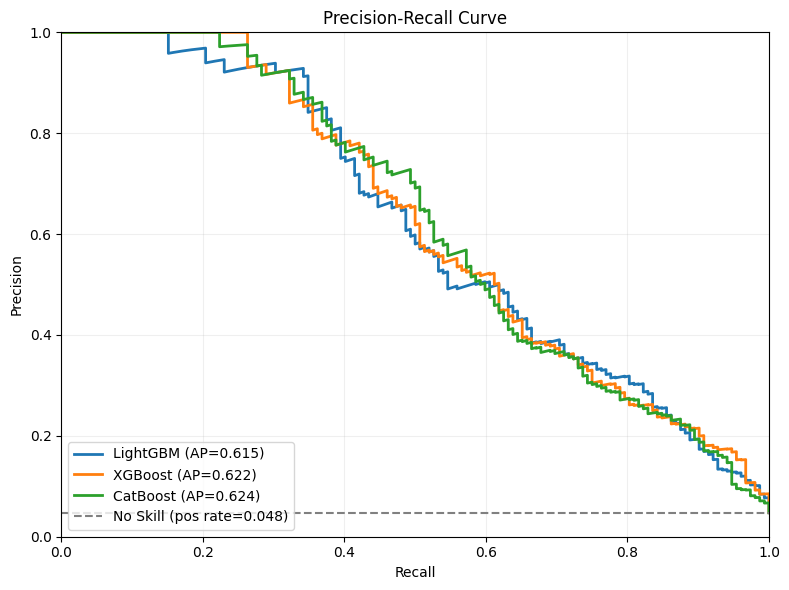

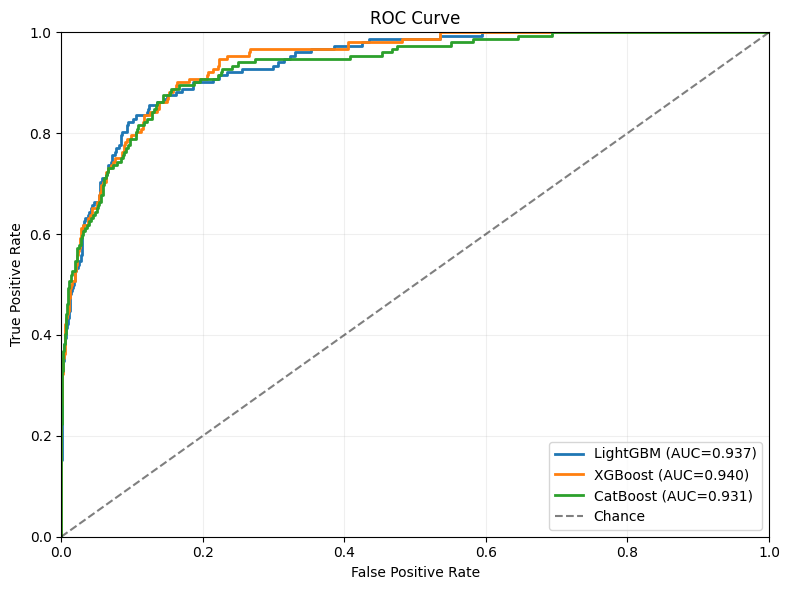

In [73]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc, roc_auc_score

import matplotlib.pyplot as plt

models = {
    'LightGBM': best_lgb,
    'XGBoost': best_xgb,
    'CatBoost': best_cb
}

# get scores
scores = {name: m.predict_proba(x_test)[:, 1] for name, m in models.items()}
pos_rate = y_test.mean()

# Precision-Recall plot
plt.figure(figsize=(8, 6))
for name, sc in scores.items():
    prec, rec, _ = precision_recall_curve(y_test, sc)
    ap = average_precision_score(y_test, sc)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})", lw=2)
plt.hlines(pos_rate, 0, 1, colors='grey', linestyles='--', label=f'No Skill (pos rate={pos_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ROC plot
plt.figure(figsize=(8, 6))
for name, sc in scores.items():
    fpr, tpr, _ = roc_curve(y_test, sc)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== MODEL METRIC SUMMARY ===
             auc      ap  accuracy      f1  precision  recall   brier  \
model                                                                   
LightGBM  0.9367  0.6154    0.9666  0.5244     0.8082  0.3882  0.0279   
XGBoost   0.9399  0.6222    0.9662  0.5424     0.7619  0.4211  0.0288   
CatBoost  0.9310  0.6239    0.9662  0.5091     0.8235  0.3684  0.0271   

          auc_ci_lower  auc_ci_upper  ap_ci_lower  ap_ci_upper  
model                                                           
LightGBM        0.9174        0.9538       0.5449       0.6862  
XGBoost         0.9234        0.9563       0.5535       0.6913  
CatBoost        0.9087        0.9499       0.5533       0.6952  

=== PAIRWISE STATISTICAL COMPARISON ===
    model_a   model_b  auc_diff_mean  auc_diff_p  ap_diff_mean  ap_diff_p  \
0  LightGBM   XGBoost        -0.0035       0.484       -0.0075      0.566   
1  LightGBM  CatBoost         0.0058       0.196       -0.0083      0.472   
2   XGBo

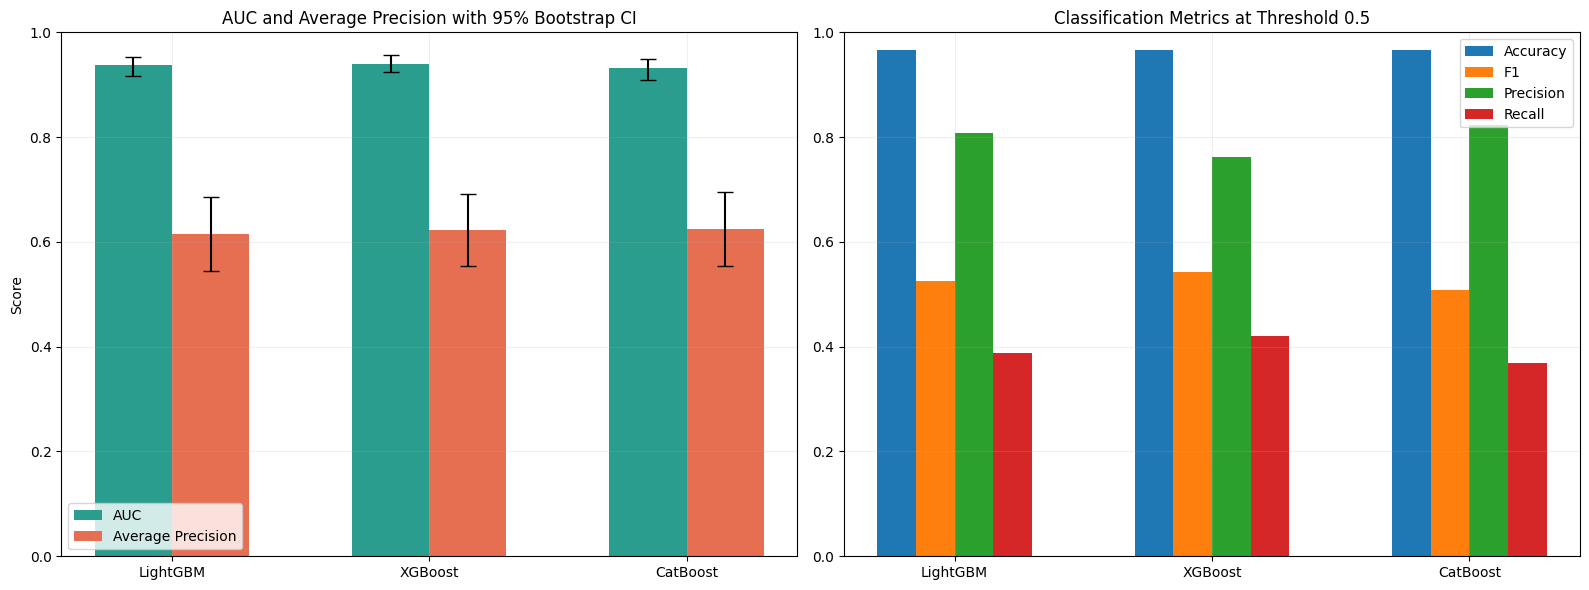

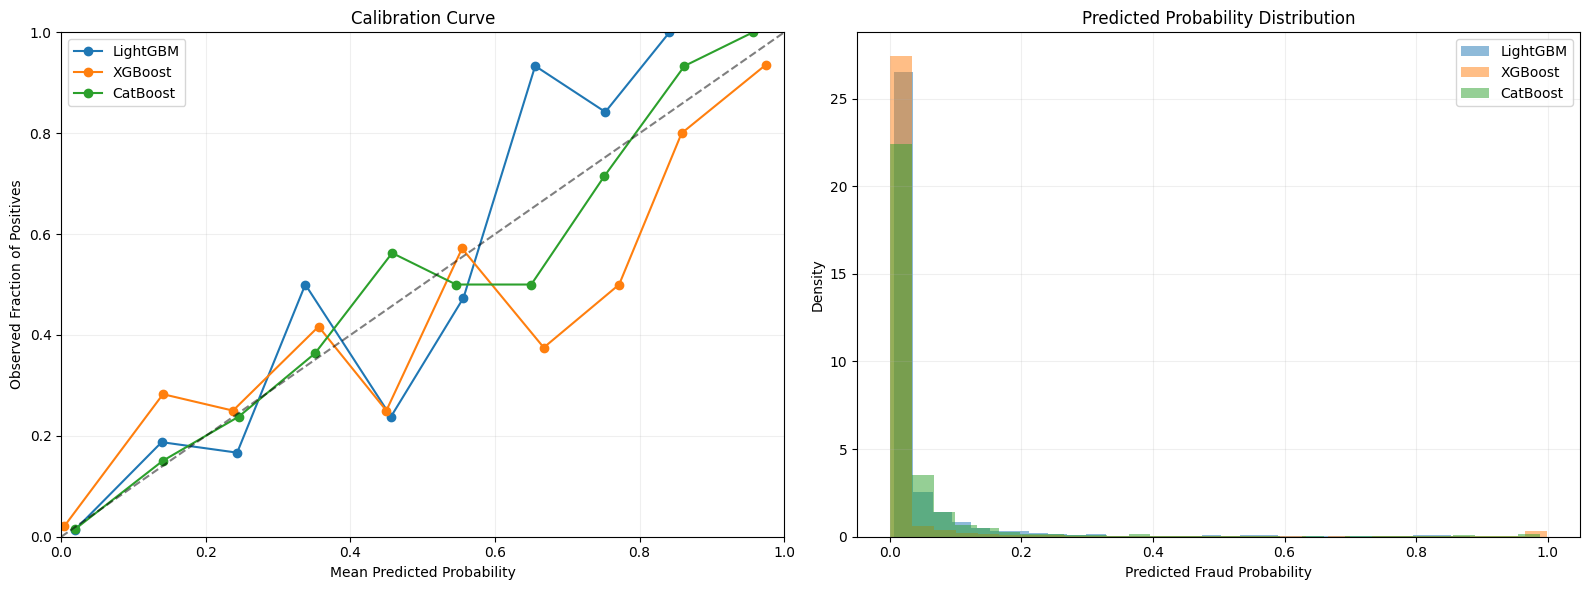

In [ ]:
#model comparison with statistical tests and agreement analysis
from itertools import combinations
from scipy.stats import binomtest
from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    cohen_kappa_score, f1_score, precision_score, recall_score,
    roc_auc_score
)

model_names = ['LightGBM', 'XGBoost', 'CatBoost']
y_scores = {name: models[name].predict_proba(x_test)[:, 1] for name in model_names}
y_preds = {name: (y_scores[name] >= 0.5).astype(int) for name in model_names}

def bootstrap_metric(y_true, y_score, metric, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    stats = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_b = y_true[idx]
        score_b = y_score[idx]
        if np.unique(y_b).size < 2:
            continue
        stats.append(metric(y_b, score_b))
    return np.array(stats)

def mcnemar_test(y_true, pred_a, pred_b):
    b = np.sum((pred_a != y_true) & (pred_b == y_true))
    c = np.sum((pred_a == y_true) & (pred_b != y_true))
    n = b + c
    if n == 0:
        return b, c, np.nan
    p_val = binomtest(min(b, c), n=n, p=0.5).pvalue
    return b, c, p_val

summary_rows = []
bootstrap_results = {}

for name in model_names:
    probs = y_scores[name]
    preds = y_preds[name]

    auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    summary_rows.append({
        'model': name,
        'auc': auc,
        'ap': ap,
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds, zero_division=0),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'brier': brier_score_loss(y_test, probs)
    })

    bootstrap_results[name] = {
        'auc': bootstrap_metric(y_test, probs, roc_auc_score, n_boot=1000),
        'ap': bootstrap_metric(y_test, probs, average_precision_score, n_boot=1000),
    }

metrics_df = pd.DataFrame(summary_rows).set_index('model')

for name in model_names:
    auc_boot = bootstrap_results[name]['auc']
    ap_boot = bootstrap_results[name]['ap']
    metrics_df.loc[name, 'auc_ci_lower'] = np.percentile(auc_boot, 2.5)
    metrics_df.loc[name, 'auc_ci_upper'] = np.percentile(auc_boot, 97.5)
    metrics_df.loc[name, 'ap_ci_lower'] = np.percentile(ap_boot, 2.5)
    metrics_df.loc[name, 'ap_ci_upper'] = np.percentile(ap_boot, 97.5)

pairwise_rows = []
agreement = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
kappa = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for a, b in combinations(model_names, 2):
    auc_diff = bootstrap_results[a]['auc'] - bootstrap_results[b]['auc']
    ap_diff = bootstrap_results[a]['ap'] - bootstrap_results[b]['ap']
    auc_p = 2 * min(np.mean(auc_diff > 0), np.mean(auc_diff < 0))
    ap_p = 2 * min(np.mean(ap_diff > 0), np.mean(ap_diff < 0))

    b, c, mcnemar_p = mcnemar_test(y_test, y_preds[a], y_preds[b])
    for a, b in combinations(model_names, 2):
        auc_diff = bootstrap_results[a]['auc'] - bootstrap_results[b]['auc']
        ap_diff = bootstrap_results[a]['ap'] - bootstrap_results[b]['ap']
        auc_p = 2 * min(np.mean(auc_diff > 0), np.mean(auc_diff < 0))
        ap_p = 2 * min(np.mean(ap_diff > 0), np.mean(ap_diff < 0))

        agreement_value = np.mean(np.asarray(y_preds[a]) == np.asarray(y_preds[b]))
        b_count, c_count, mcnemar_p = mcnemar_test(y_test, y_preds[a], y_preds[b])
        kappa_value = cohen_kappa_score(y_preds[a], y_preds[b])

        pairwise_rows.append({
            'model_a': a,
            'model_b': b,
            'auc_diff_mean': auc_diff.mean(),
            'auc_diff_p': auc_p,
            'ap_diff_mean': ap_diff.mean(),
            'ap_diff_p': ap_p,
            'mcnemar_b': b_count,
            'mcnemar_c': c_count,
            'mcnemar_p': mcnemar_p,
            'prediction_agreement': agreement_value,
            'cohen_kappa': kappa_value
        })

        agreement.loc[a, b] = agreement.loc[b, a] = agreement_value
        kappa.loc[a, b] = kappa.loc[b, a] = kappa_value
        agreement.loc[a, a] = kappa.loc[a, a] = 1.0
        agreement.loc[b, b] = kappa.loc[b, b] = 1.0
    b, c, mcnemar_p = mcnemar_test(y_test, y_preds[a], y_preds[b])
    # Replace the whole pairwise comparison block with this to avoid variable shadowing
    pairwise_rows = []
    agreement = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
    kappa = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

    for a, b in combinations(model_names, 2):
        auc_diff = bootstrap_results[a]['auc'] - bootstrap_results[b]['auc']
        ap_diff = bootstrap_results[a]['ap'] - bootstrap_results[b]['ap']
        auc_p = 2 * min(np.mean(auc_diff > 0), np.mean(auc_diff < 0))
        ap_p = 2 * min(np.mean(ap_diff > 0), np.mean(ap_diff < 0))

        b_count, c_count, mcnemar_p = mcnemar_test(y_test, y_preds[a], y_preds[b])
        agreement_value = np.mean(np.asarray(y_preds[a]) == np.asarray(y_preds[b]))
        kappa_value = cohen_kappa_score(y_preds[a], y_preds[b])

        pairwise_rows.append({
            'model_a': a,
            'model_b': b,
            'auc_diff_mean': auc_diff.mean(),
            'auc_diff_p': auc_p,
            'ap_diff_mean': ap_diff.mean(),
            'ap_diff_p': ap_p,
            'mcnemar_b': b_count,
            'mcnemar_c': c_count,
            'mcnemar_p': mcnemar_p,
            'prediction_agreement': agreement_value,
            'cohen_kappa': kappa_value
        })

        agreement.loc[a, b] = agreement.loc[b, a] = agreement_value
        kappa.loc[a, b] = kappa.loc[b, a] = kappa_value

    # set diagonals
    for m in model_names:
        agreement.loc[m, m] = 1.0
        kappa.loc[m, m] = 1.0

    pairwise_df = pd.DataFrame(pairwise_rows)

    pairwise_rows.append({
        'model_a': a,
        'model_b': b,
        'auc_diff_mean': auc_diff.mean(),
        'auc_diff_p': auc_p,
        'ap_diff_mean': ap_diff.mean(),
        'ap_diff_p': ap_p,
        'mcnemar_b': b,
        'mcnemar_c': c,
        'mcnemar_p': mcnemar_p,
        'prediction_agreement': agreement_value,
        'cohen_kappa': kappa_value
    })

    agreement.loc[a, b] = agreement.loc[b, a] = agreement_value
    kappa.loc[a, b] = kappa.loc[b, a] = kappa_value
    agreement.loc[a, a] = kappa.loc[a, a] = 1.0
    agreement.loc[b, b] = kappa.loc[b, b] = 1.0

pairwise_df = pd.DataFrame(pairwise_rows)

print("=== MODEL METRIC SUMMARY ===")
print(metrics_df.round(4))

print("\n=== PAIRWISE STATISTICAL COMPARISON ===")
print(pairwise_df[['model_a', 'model_b', 'auc_diff_mean', 'auc_diff_p', 'ap_diff_mean', 'ap_diff_p', 'mcnemar_b', 'mcnemar_c', 'mcnemar_p', 'prediction_agreement', 'cohen_kappa']].round(4))

print("\n=== PREDICTION AGREEMENT MATRIX ===")
print(agreement.round(4))

print("\n=== COHEN'S KAPPA MATRIX ===")
print(kappa.round(4))

# Visual comparison
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(model_names))
width = 0.3

axs[0].bar(x - width/2, metrics_df['auc'], width, yerr=[metrics_df['auc'] - metrics_df['auc_ci_lower'], metrics_df['auc_ci_upper'] - metrics_df['auc']],
           capsize=6, label='AUC', color='#2a9d8f')
axs[0].bar(x + width/2, metrics_df['ap'], width,
           yerr=[metrics_df['ap'] - metrics_df['ap_ci_lower'], metrics_df['ap_ci_upper'] - metrics_df['ap']],
           capsize=6, label='Average Precision', color='#e76f51')
axs[0].set_xticks(x)
axs[0].set_xticklabels(model_names)
axs[0].set_ylim(0, 1.0)
axs[0].set_ylabel('Score')
axs[0].set_title('AUC and Average Precision with 95% Bootstrap CI')
axs[0].legend()
axs[0].grid(alpha=0.2)

for idx, metric in enumerate(['accuracy', 'f1', 'precision', 'recall']):
    axs[1].bar(x + (idx - 1.5) * (width / 2), metrics_df[metric], width / 2, label=metric.capitalize())
axs[1].set_xticks(x)
axs[1].set_xticklabels(model_names)
axs[1].set_ylim(0, 1.0)
axs[1].set_title('Classification Metrics at Threshold 0.5')
axs[1].legend()
axs[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for name in model_names:
    prob_true, prob_pred = calibration_curve(y_test, y_scores[name], n_bins=10)
    axs[0].plot(prob_pred, prob_true, marker='o', label=name)
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)
axs[0].set_xlabel('Mean Predicted Probability')
axs[0].set_ylabel('Observed Fraction of Positives')
axs[0].set_title('Calibration Curve')
axs[0].legend()
axs[0].grid(alpha=0.2)

for name in model_names:
    axs[1].hist(y_scores[name], bins=30, alpha=0.5, density=True, label=name)
axs[1].set_xlabel('Predicted Fraud Probability')
axs[1].set_ylabel('Density')
axs[1].set_title('Predicted Probability Distribution')
axs[1].legend()
axs[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [87]:
import shap
for model_name, model in [('LightGBM', best_lgb), ('XGBoost', best_xgb), ('CatBoost', best_cb)]:
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(x_test)
    
    # Calculate feature importance
    feature_importance = np.abs(shap_vals).mean(axis=0)
    
    # Get top 5 features
    top5_indices = np.argsort(feature_importance)[-5:][::-1]
    
    print(f"\n{model_name} Top 5 features:")
    for rank, idx in enumerate(top5_indices, start=1):
        print(f"  {rank}. {feature_names[idx]}: {feature_importance[idx]:.4f}")


LightGBM Top 5 features:
  1. monthly_pool_amount_max: 0.5581
  2. current_approval_amount_sum: 0.1623
  3. basic_pool_fund_payment_sum: 0.1512
  4. pooled_payment_amount_sum: 0.1149
  5. herbal_medicine_sum: 0.1131

XGBoost Top 5 features:
  1. monthly_pool_amount_max: 1.4955
  2. monthly_drug_amount_max: 0.5579
  3. herbal_medicine_sum: 0.3599
  4. monthly_visit_days_avg: 0.3290
  5. basic_pool_fund_payment_sum: 0.2790

CatBoost Top 5 features:
  1. monthly_pool_amount_max: 0.5657
  2. herbal_medicine_sum: 0.2869
  3. monthly_drug_amount_max: 0.2336
  4. basic_pool_fund_payment_sum: 0.1615
  5. current_approval_amount_sum: 0.1215


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_1616\3429882630.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, feature_names=feature_names, show=False)


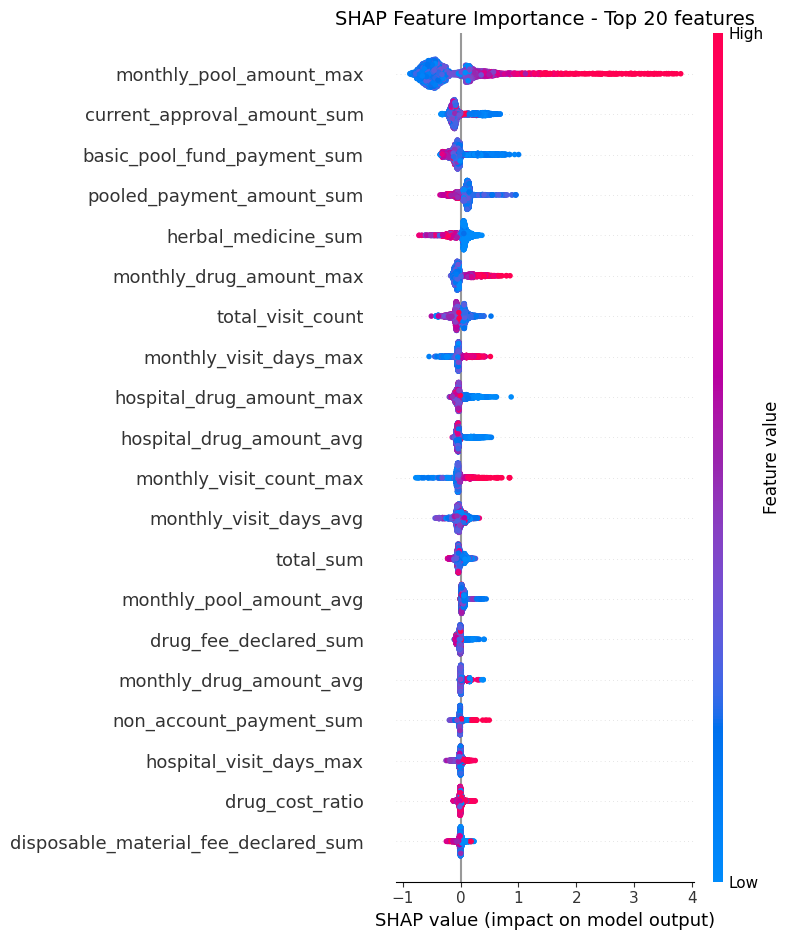

In [75]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(x_test)
feature_names = df.drop(columns = ['res']).columns.tolist()

shap.summary_plot(shap_values, x_test, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance - Top 20 features", fontsize=14)
plt.tight_layout()
plt.show()

Scale Pos Weight: 18.97
FIDELITY CURVE: Performance vs. Number of Features
Top 10 features (new ranking):
  1. monthly_pool_amount_max
  2. current_approval_amount_sum
  3. basic_pool_fund_payment_sum
  4. pooled_payment_amount_sum
  5. herbal_medicine_sum
  6. monthly_drug_amount_max
  7. total_visit_count
  8. monthly_visit_days_max
  9. hospital_drug_amount_max
  10. hospital_drug_amount_avg
  Features:   1 → F1: 0.2801 | Accuracy: 0.8506


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Features:   2 → F1: 0.3315 | Accuracy: 0.8500
  Features:   3 → F1: 0.3397 | Accuracy: 0.8591


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Features:   5 → F1: 0.3612 | Accuracy: 0.8662
  Features:  10 → F1: 0.3974 | Accuracy: 0.8862


...

C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Features:  30 → F1: 0.4367 | Accuracy: 0.9041


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Features:  50 → F1: 0.4531 | Accuracy: 0.9125
  Features:  75 → F1: 0.4591 | Accuracy: 0.9131

 95% of full F1 (0.4591) achieved with 20 features


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


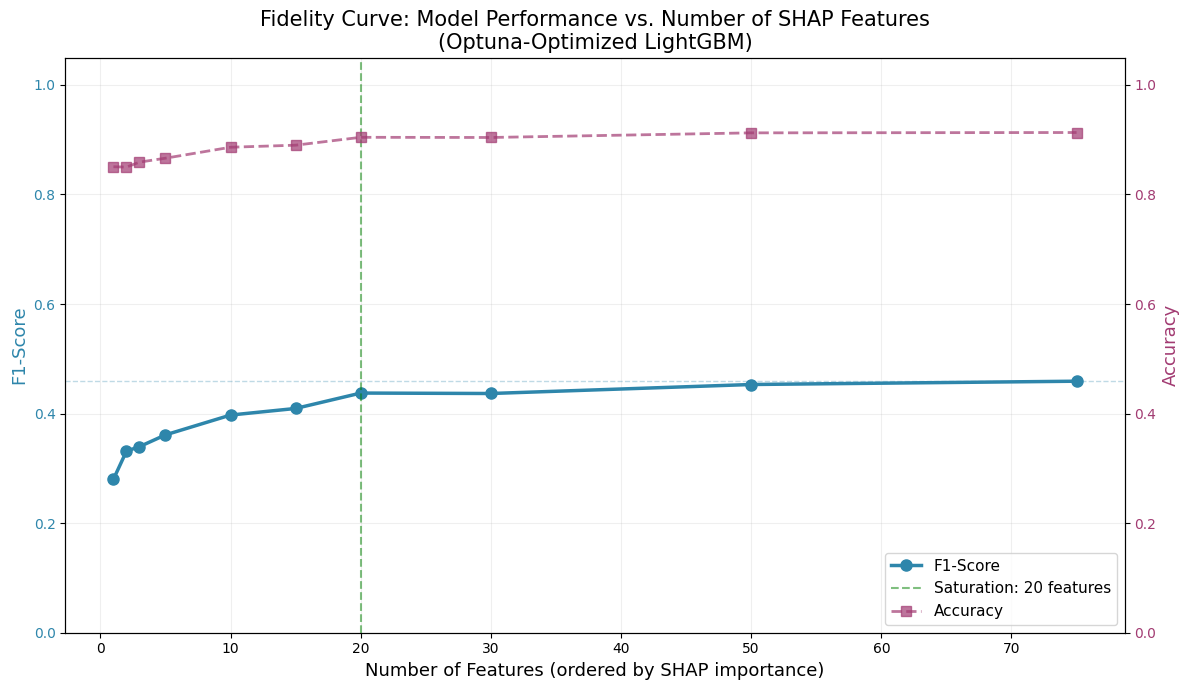


FIDELITY CURVE SUMMARY
Full model (75 features) F1:      0.4591
Top-5 features F1:                0.3612 (78.7% of full)
Top-10 features F1:               0.3974 (86.5% of full)
Top-20 features F1:               0.4375 (95.3% of full)
Saturation point:                 20 features → 0.4375 F1


In [76]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Recalculate scale_pos_weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

print("="*60)
print("FIDELITY CURVE: Performance vs. Number of Features")
print("="*60)

# 1. Get feature importance ranking from NEW SHAP values
importance_ranking = np.argsort(np.abs(shap_values).mean(axis=0))[::-1]
print("Top 10 features (new ranking):")
for i, idx in enumerate(importance_ranking[:10]):
    print(f"  {i+1}. {feature_names[idx]}")

# 2. Test with increasing number of features
feature_counts = [1, 2, 3, 5, 10, 15, 20, 30, 50, x_train.shape[1]]
fidelity_f1 = []
fidelity_acc = []

best_params_lgb = best_lgb.get_params()
for key in ['random_state', 'verbose', 'scale_pos_weight']:
    best_params_lgb.pop(key, None)

if 'best_params_dict' not in globals() or 'LightGBM' not in best_params_dict:
    best_params_dict = {'LightGBM': best_params_lgb.copy()}
else:
    for key in ['random_state', 'verbose', 'scale_pos_weight']:
        best_params_dict['LightGBM'].pop(key, None)

for k in feature_counts:
    top_k_idx = importance_ranking[:k]
    x_train_k = x_train[:, top_k_idx]
    x_test_k = x_test[:, top_k_idx]
    
    model_k = lgb.LGBMClassifier(
        **best_params_dict['LightGBM'],  # Use saved / Optuna params
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbose=-1
    )
    model_k.fit(x_train_k, y_train)
    y_pred_k = model_k.predict(x_test_k)
    
    f1_k = f1_score(y_test, y_pred_k)
    acc_k = accuracy_score(y_test, y_pred_k)
    fidelity_f1.append(f1_k)
    fidelity_acc.append(acc_k)
    print(f"  Features: {k:3d} → F1: {f1_k:.4f} | Accuracy: {acc_k:.4f}")

# 3. Find "saturation point" (95% of full F1)
full_f1 = fidelity_f1[-1]
saturation_idx = next(i for i, f1 in enumerate(fidelity_f1) if f1 >= 0.95 * full_f1)
print(f"\n 95% of full F1 ({full_f1:.4f}) achieved with {feature_counts[saturation_idx]} features")

# 4. Plot Fidelity Curve
fig, ax1 = plt.subplots(figsize=(12, 7))

color_f1 = '#2E86AB'
color_acc = '#A23B72'

ax1.plot(feature_counts, fidelity_f1, 'o-', color=color_f1, linewidth=2.5, markersize=8, label='F1-Score')
ax1.axhline(y=full_f1, color=color_f1, linestyle='--', alpha=0.3, linewidth=1)
ax1.axvline(x=feature_counts[saturation_idx], color='green', linestyle='--', alpha=0.5, 
            label=f'Saturation: {feature_counts[saturation_idx]} features')
ax1.set_xlabel('Number of Features (ordered by SHAP importance)', fontsize=13)
ax1.set_ylabel('F1-Score', fontsize=13, color=color_f1)
ax1.tick_params(axis='y', labelcolor=color_f1)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(feature_counts, fidelity_acc, 's--', color=color_acc, linewidth=2, markersize=7, alpha=0.7, label='Accuracy')
ax2.set_ylabel('Accuracy', fontsize=13, color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=11)

plt.title('Fidelity Curve: Model Performance vs. Number of SHAP Features\n(Optuna-Optimized LightGBM)', fontsize=15)
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 5. Summary 
print("\n" + "="*60)
print("FIDELITY CURVE SUMMARY")
print("="*60)
print(f"Full model (75 features) F1:      {full_f1:.4f}")
print(f"Top-5 features F1:                {fidelity_f1[3]:.4f} ({(fidelity_f1[3]/full_f1)*100:.1f}% of full)")
print(f"Top-10 features F1:               {fidelity_f1[4]:.4f} ({(fidelity_f1[4]/full_f1)*100:.1f}% of full)")
print(f"Top-20 features F1:               {fidelity_f1[6]:.4f} ({(fidelity_f1[6]/full_f1)*100:.1f}% of full)")
print(f"Saturation point:                 {feature_counts[saturation_idx]} features → {fidelity_f1[saturation_idx]:.4f} F1")

Results

Even with the top 5 SHAP features, the simplified model loses 22% of its fraud detection power. This proves that the original model relies on a complex, non-linear interaction of many features, not just the most important ones."

In [77]:
# ================= STABILITY ANALYSIS - COMPREHENSIVE =================
from scipy.stats import kendalltau

print("\n" + "="*60)
print("STABILITY ANALYSIS - COMPREHENSIVE REPORT")
print("="*60)

# 1. Calculate ASE for multiple noise levels
noise_levels = [0.01, 0.05, 0.10]
stability_results = []

for sigma in noise_levels:
    np.random.seed(42)
    noise = np.random.normal(0, sigma, size=x_test.shape)
    X_test_noisy = x_test + noise
    shap_noisy = explainer.shap_values(X_test_noisy)
    ase = np.mean(np.abs(shap_values - shap_noisy))
    stability_results.append({'Noise Level (σ)': sigma, 'ASE': ase})

# 2. Print ASE results
print("\n--- Average Stability Error (ASE) ---")
for result in stability_results:
    print(f"σ = {result['Noise Level (σ)']:.2f}  →  ASE = {result['ASE']:.6f}")

# 3. Kendall τ for FULL ranking (81 features)
original_importance = np.abs(shap_values).mean(axis=0)
noisy_importance = np.abs(explainer.shap_values(x_test + np.random.normal(0, 0.05, size=x_test.shape))).mean(axis=0)
tau_full, p_full = kendalltau(original_importance, noisy_importance)
print(f"\n--- Kendall τ (Full 81 features, σ=0.05) ---")
print(f"τ = {tau_full:.4f}")
print(f"p-value = {p_full:.4f}")
print(f"Interpretation: {'Statistically significant' if p_full < 0.05 else 'Not statistically significant'}")

# 4. Kendall τ for TOP 20 features only (more relevant for explanation)
top20_indices = np.argsort(original_importance)[-20:]
tau_top20, p_top20 = kendalltau(
    original_importance[top20_indices], 
    noisy_importance[top20_indices]
)
print(f"\n--- Kendall τ (Top 20 features only, σ=0.05) ---")
print(f"τ = {tau_top20:.4f}")
print(f"p-value = {p_top20:.4f}")
print(f"Interpretation: {'Statistically significant' if p_top20 < 0.05 else 'Not statistically significant'}")

# 5. Automatic conclusion
print("\n" + "="*60)
print("STABILITY ANALYSIS CONCLUSION")
print("="*60)
print(f" ASE remains low across all noise levels (max {max(r['ASE'] for r in stability_results):.4f}),")
print(f" indicating that SHAP values are numerically stable and trustworthy.")
if tau_full < 0.3:
    print(f"  Kendall τ for full feature ranking is low ({tau_full:.2f}),")
    print(f"  suggesting rank-order sensitivity due to many features having similar importance.")
    print(f"  This implies: Use SHAP values (magnitudes) for individual explanations,")
    print(f"  and treat global feature rankings with caution when features are similarly important.")
if tau_top20 > tau_full:
    print(f" Kendall τ for Top 20 features is higher ({tau_top20:.2f}),")
    print(f" confirming that the most important features maintain relative stability.")


STABILITY ANALYSIS - COMPREHENSIVE REPORT


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



--- Average Stability Error (ASE) ---
σ = 0.01  →  ASE = 0.001311
σ = 0.05  →  ASE = 0.002404
σ = 0.10  →  ASE = 0.003081

--- Kendall τ (Full 81 features, σ=0.05) ---
τ = 0.9711
p-value = 0.0000
Interpretation: Statistically significant

--- Kendall τ (Top 20 features only, σ=0.05) ---
τ = 0.9684
p-value = 0.0000
Interpretation: Statistically significant

STABILITY ANALYSIS CONCLUSION
 ASE remains low across all noise levels (max 0.0031),
 indicating that SHAP values are numerically stable and trustworthy.


STABILITY ANALYSIS: VISUAL SUMMARY
   sigma  ase_mean   ase_std  tau_full_mean  tau_full_std  tau_top20_mean  \
0   0.01  0.001339  0.000023       0.977660      0.000579        0.978947   
1   0.03  0.001972  0.000025       0.972933      0.000524        0.978947   
2   0.05  0.002402  0.000034       0.967742      0.000981        0.972368   
3   0.10  0.003066  0.000039       0.956804      0.000718        0.947368   

   tau_top20_std  overlap_5  overlap_10  overlap_20  
0       0.000000        5.0         9.0      20.000  
1       0.000000        5.0         9.0      19.875  
2       0.005096        5.0         9.0      19.000  
3       0.000000        5.0         9.0      19.000  


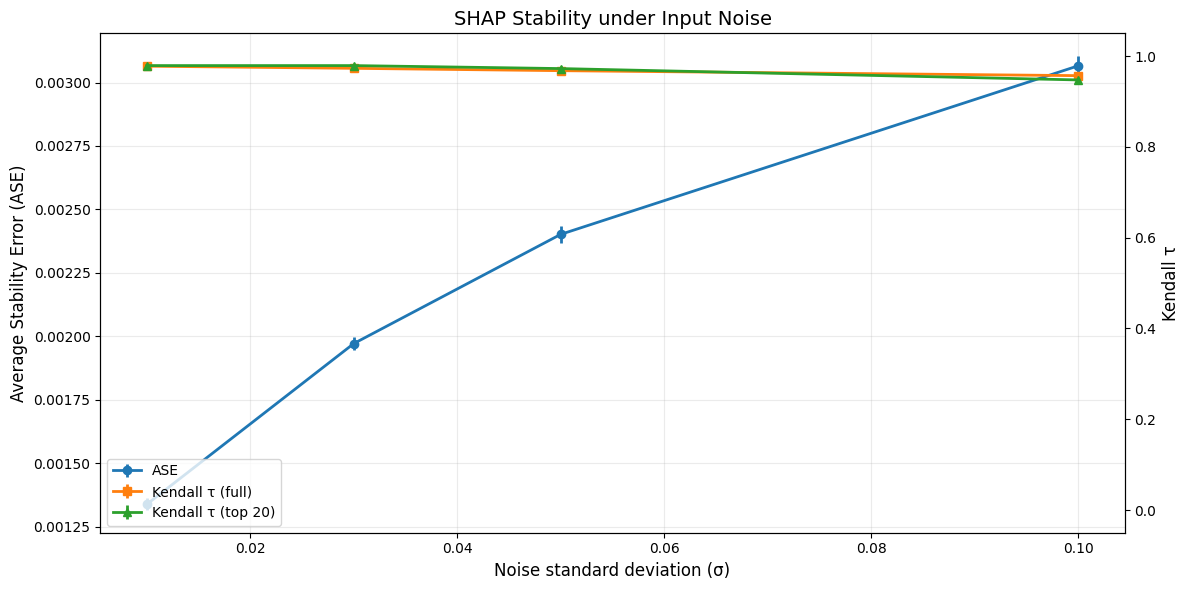

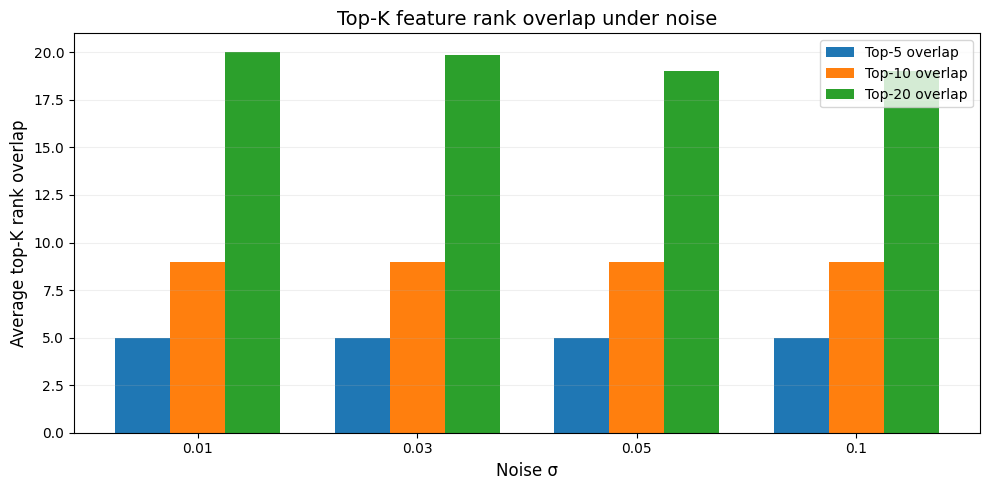

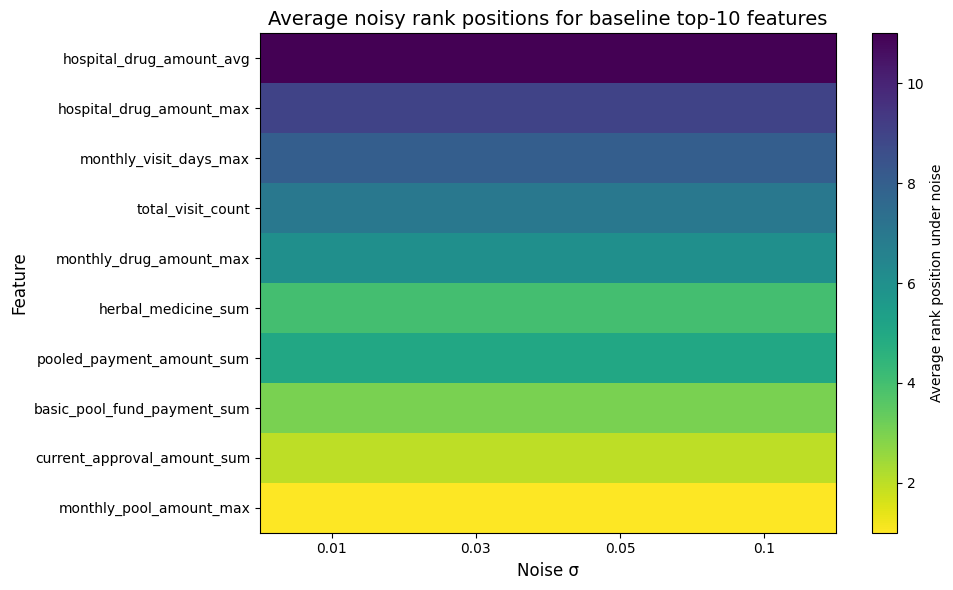


Top 10 baseline features and their average noisy rank at σ=0.05
  1. monthly_pool_amount_max: avg. noisy rank = 1.0
  2. current_approval_amount_sum: avg. noisy rank = 2.0
  3. basic_pool_fund_payment_sum: avg. noisy rank = 3.0
  4. pooled_payment_amount_sum: avg. noisy rank = 5.0
  5. herbal_medicine_sum: avg. noisy rank = 4.0
  6. monthly_drug_amount_max: avg. noisy rank = 6.0
  7. total_visit_count: avg. noisy rank = 7.0
  8. monthly_visit_days_max: avg. noisy rank = 8.0
  9. hospital_drug_amount_max: avg. noisy rank = 9.0
  10. hospital_drug_amount_avg: avg. noisy rank = 11.0


In [78]:
print("STABILITY ANALYSIS: VISUAL SUMMARY")
print("=" * 70)

baseline_importance = np.abs(shap_values).mean(axis=0)
baseline_rank = np.argsort(baseline_importance)[::-1]
baseline_top10 = baseline_rank[:10]
baseline_top10_names = [feature_names[i] for i in baseline_top10]

noise_levels = [0.01, 0.03, 0.05, 0.10]
repeats = 8

records = []
rank_matrix = np.zeros((len(baseline_top10), len(noise_levels)), dtype=float)

for j, sigma in enumerate(noise_levels):
    ase_vals = []
    tau_full_vals = []
    tau_top20_vals = []
    overlap_counts = {5: [], 10: [], 20: []}
    top10_rank_positions = [[] for _ in baseline_top10]

    for rep in range(repeats):
        np.random.seed(1000 + rep)
        X_noise = x_test + np.random.normal(0, sigma, x_test.shape)
        shap_noise = explainer.shap_values(X_noise)
        importance_noise = np.abs(shap_noise).mean(axis=0)

        ase_vals.append(np.mean(np.abs(shap_values - shap_noise)))

        tau_full = kendalltau(baseline_importance, importance_noise)[0]
        tau_full_vals.append(0.0 if np.isnan(tau_full) else tau_full)

        noise_rank = np.argsort(importance_noise)[::-1]
        top20_noise = noise_rank[:20]
        tau_top20 = kendalltau(baseline_importance[top20_noise], importance_noise[top20_noise])[0]
        tau_top20_vals.append(0.0 if np.isnan(tau_top20) else tau_top20)

        for k in overlap_counts:
            overlap_counts[k].append(len(set(baseline_rank[:k]).intersection(set(noise_rank[:k]))))

        for i, idx in enumerate(baseline_top10):
            rank_positions = np.where(noise_rank == idx)[0][0] + 1
            top10_rank_positions[i].append(rank_positions)

    records.append({
        'sigma': sigma,
        'ase_mean': np.mean(ase_vals),
        'ase_std': np.std(ase_vals),
        'tau_full_mean': np.mean(tau_full_vals),
        'tau_full_std': np.std(tau_full_vals),
        'tau_top20_mean': np.mean(tau_top20_vals),
        'tau_top20_std': np.std(tau_top20_vals),
        'overlap_5': np.mean(overlap_counts[5]),
        'overlap_10': np.mean(overlap_counts[10]),
        'overlap_20': np.mean(overlap_counts[20])
    })

    for i in range(len(baseline_top10)):
        rank_matrix[i, j] = np.mean(top10_rank_positions[i])

stability_df = pd.DataFrame(records)
print(stability_df)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.errorbar(stability_df['sigma'], stability_df['ase_mean'], yerr=stability_df['ase_std'],
             marker='o', color='#1f77b4', label='ASE', linewidth=2)
ax1.set_xlabel('Noise standard deviation (σ)', fontsize=12)
ax1.set_ylabel('Average Stability Error (ASE)', fontsize=12)
ax1.set_title('SHAP Stability under Input Noise', fontsize=14)
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.errorbar(stability_df['sigma'], stability_df['tau_full_mean'], yerr=stability_df['tau_full_std'],
             marker='s', color='#ff7f0e', label='Kendall τ (full)', linewidth=2)
ax2.errorbar(stability_df['sigma'], stability_df['tau_top20_mean'], yerr=stability_df['tau_top20_std'],
             marker='^', color='#2ca02c', label='Kendall τ (top 20)', linewidth=2)
ax2.set_ylabel('Kendall τ', fontsize=12)
ax2.set_ylim(-0.05, 1.05)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
x = np.arange(len(noise_levels))
width = 0.25
plt.bar(x - width, stability_df['overlap_5'], width, label='Top-5 overlap')
plt.bar(x, stability_df['overlap_10'], width, label='Top-10 overlap')
plt.bar(x + width, stability_df['overlap_20'], width, label='Top-20 overlap')
plt.xticks(x, noise_levels)
plt.xlabel('Noise σ', fontsize=12)
plt.ylabel('Average top-K rank overlap', fontsize=12)
plt.title('Top-K feature rank overlap under noise', fontsize=14)
plt.legend()
plt.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
im = plt.imshow(rank_matrix, aspect='auto', cmap='viridis_r')
plt.colorbar(im, label='Average rank position under noise')
plt.yticks(np.arange(len(baseline_top10)), baseline_top10_names)
plt.xticks(np.arange(len(noise_levels)), noise_levels)
plt.gca().invert_yaxis()
plt.title('Average noisy rank positions for baseline top-10 features', fontsize=14)
plt.xlabel('Noise σ', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 baseline features and their average noisy rank at σ=0.05")
for i, name in enumerate(baseline_top10_names):
    print(f"  {i+1}. {name}: avg. noisy rank = {rank_matrix[i, 2]:.1f}")

In [79]:
importance = np.abs(shap_values).mean(axis=0)
top5_new_idx = np.argsort(importance)[-5:][::-1]  
top5_new_names = [feature_names[i] for i in top5_new_idx]

print("Top 5 SHAP Features (After Optuna):")
for i, (name, idx) in enumerate(zip(top5_new_names, top5_new_idx)):
    print(f"  {i+1}. {name} (importance: {importance[idx]:.4f})")

Top 5 SHAP Features (After Optuna):
  1. monthly_pool_amount_max (importance: 0.5581)
  2. current_approval_amount_sum (importance: 0.1623)
  3. basic_pool_fund_payment_sum (importance: 0.1512)
  4. pooled_payment_amount_sum (importance: 0.1149)
  5. herbal_medicine_sum (importance: 0.1131)


In [ ]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

print("\n" + "=" * 60)
print("COUNTERFACTUAL ANALYSIS WITH BAYESIAN OPTIMIZATION (LightGBM)")
print("=" * 60)

final_model = model

fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]
original_instance = x_test[sample_idx]

prob_original = final_model.predict_proba([original_instance])[0, 1]
print(f"Selected Sample Index: {sample_idx}")
print(f"Original Fraud Probability: {prob_original:.4f}")

top5_names = top5_new_names   
top5_indices = top5_new_idx  
print(f"Optimizing Top-5 SHAP features: {top5_names}")


space = []
for idx, name in zip(top5_indices, top5_names):
    orig_val = original_instance[idx]
    if orig_val == 0:
        low, high = 0.0, 1.0
    else:
        low = max(0, orig_val * 0.5)
        high = orig_val * 1.5
    space.append(Real(low, high, name=name))

@use_named_args(space)
def counterfactual_objective(**params):
    candidate = original_instance.copy()
    vals = list(params.values())
    for i, idx in enumerate(top5_indices):
        candidate[idx] = vals[i]
    
    prob = final_model.predict_proba([candidate])[0, 1]
    distance = np.linalg.norm(np.array(vals) - original_instance[top5_indices])
    penalty = 1000 if prob >= 0.5 else 0
    return distance + penalty

print("\nRunning Bayesian Optimization (30 calls)...")
res = gp_minimize(counterfactual_objective, space, n_calls=30, random_state=42)

cf_sample = original_instance.copy()
for i, idx in enumerate(top5_indices):
    cf_sample[idx] = res.x[i]

new_prob = final_model.predict_proba([cf_sample])[0, 1]

print("\n" + "=" * 60)
print("COUNTERFACTUAL RESULT")
print("=" * 60)
print(f"Original Fraud Probability: {prob_original:.4f}")
print(f"Counterfactual Probability:  {new_prob:.4f}")

if new_prob < 0.5:
    print(" Decision FLIPPED from FRAUD to NON-FRAUD!")
    print("\nOptimal changes:")
    for i, (idx, name) in enumerate(zip(top5_indices, top5_names)):
        orig = original_instance[idx]
        new = res.x[i]
        change_pct = (new - orig) / (orig + 1e-6) * 100
        print(f"  • {name}: {orig:.2f} → {new:.2f} ({change_pct:+.1f}%)")
else:
    print(" Could not flip decision with ±50% perturbation on Top-5 features.")


COUNTERFACTUAL ANALYSIS WITH BAYESIAN OPTIMIZATION (LightGBM)
Selected Sample Index: 27
Original Fraud Probability: 0.4996
Optimizing Top-5 SHAP features: ['monthly_pool_amount_max', 'current_approval_amount_sum', 'basic_pool_fund_payment_sum', 'pooled_payment_amount_sum', 'herbal_medicine_sum']

Running Bayesian Optimization (30 calls)...


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCla


COUNTERFACTUAL RESULT
Original Fraud Probability: 0.4996
Counterfactual Probability:  0.4758
 Decision FLIPPED from FRAUD to NON-FRAUD!

Optimal changes:
  • monthly_pool_amount_max: 7028.09 → 7085.55 (+0.8%)
  • current_approval_amount_sum: 18182.64 → 16934.77 (-6.9%)
  • basic_pool_fund_payment_sum: 16364.37 → 12404.36 (-24.2%)
  • pooled_payment_amount_sum: 16364.37 → 18510.19 (+13.1%)
  • herbal_medicine_sum: 5035.86 → 5381.87 (+6.9%)


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


VISUALIZATION: SHAP DEPENDENCE PLOT
Creating Dependence Plot for: monthly_pool_amount_max
Interaction feature: current_approval_amount_sum


<Figure size 1000x600 with 0 Axes>

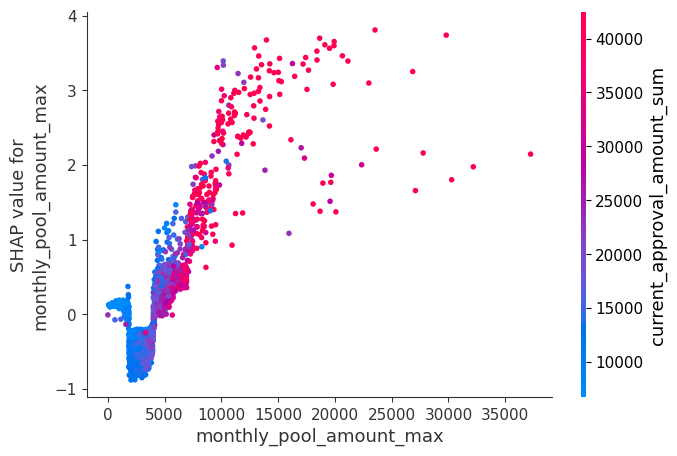

Creating second Dependence Plot for: monthly_pool_amount_max
Interaction feature: drug_cost_ratio


<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

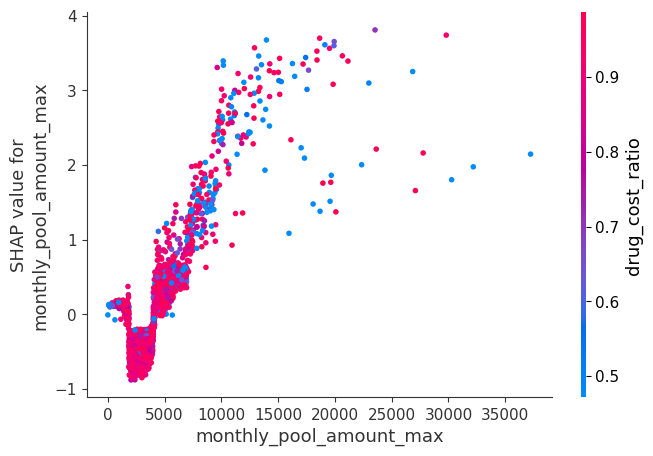

In [81]:
#VISUALIZATION: SHAP DEPENDENCE PLOT (monthly pool amount max VS current approval amount sum )
print("VISUALIZATION: SHAP DEPENDENCE PLOT")
print("="*55)

feature_names = df.drop(columns=['res']).columns.tolist()
top_feature_1 = 'monthly_pool_amount_max'
top_feature_2 = 'current_approval_amount_sum'

idx_1 = feature_names.index(top_feature_1)
idx_2 = feature_names.index(top_feature_2)

print(f"Creating Dependence Plot for: {top_feature_1}")
print(f"Interaction feature: {top_feature_2}")

# Plotting 
# shap_values = explainer.shap_values(X_test) 
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    idx_1,                     
    shap_values,               
    x_test,                    
    feature_names=feature_names, 
    interaction_index=idx_2    
)

plt.tight_layout()

# Second dependence plot: monthly_pool_amount_max vs drug_cost_ratio
second_feature_1 = 'monthly_pool_amount_max'
second_feature_2 = 'drug_cost_ratio'

idx_1b = feature_names.index(second_feature_1)
idx_2b = feature_names.index(second_feature_2)

print(f"Creating second Dependence Plot for: {second_feature_1}")
print(f"Interaction feature: {second_feature_2}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    idx_1b,
    shap_values,
    x_test,
    feature_names=feature_names,
    interaction_index=idx_2b
)
plt.title(f"SHAP Dependence Plot: {second_feature_1} vs. {second_feature_2}")
plt.tight_layout()


ERROR ANALYSIS: FALSE NEGATIVE (Missed Fraud)
Total Fraud Cases in Test Set: 152
Fraud Cases Missed by Model (FN): 93
Percentage of Fraud Missed: 61.2%

Investigating False Negative Sample Index: 27
Actual Label: 1 (Fraud)
Model Prediction: 0 (Non-Fraud)


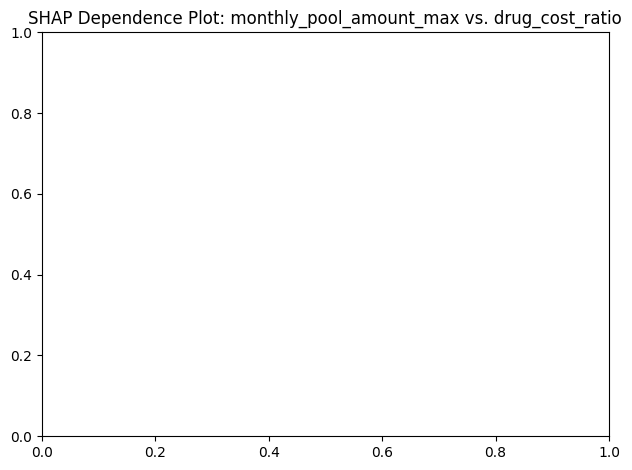

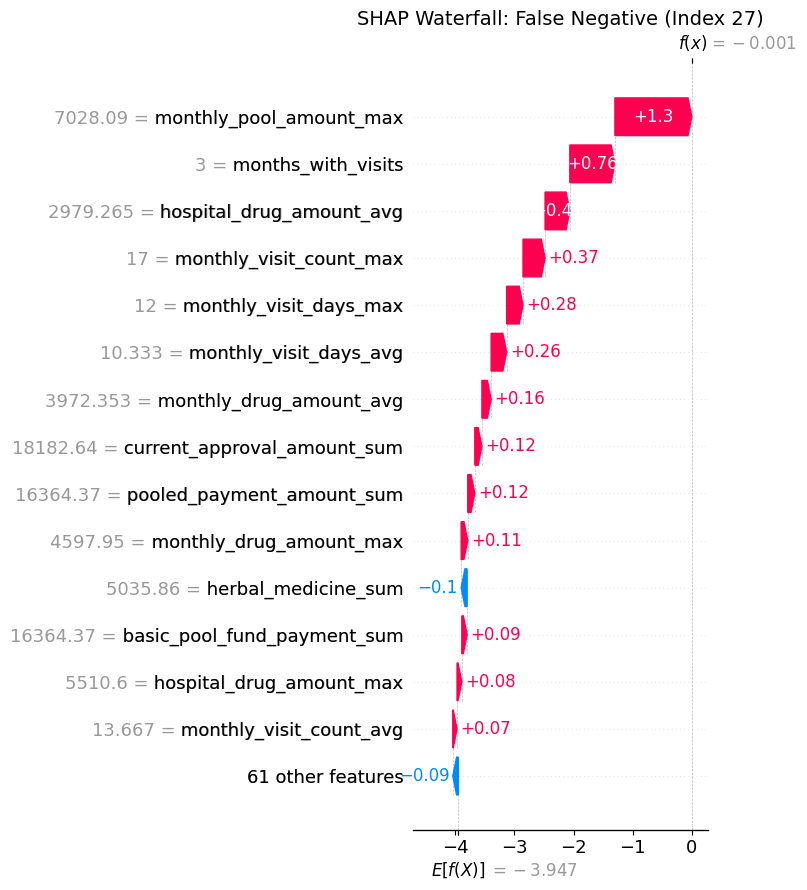

In [82]:
# ERROR ANALYSIS: FALSE NEGATIVE INVESTIGATION 
print("ERROR ANALYSIS: FALSE NEGATIVE (Missed Fraud)")
print("="*55)

# 1. Find all False Negatives in the test set
fn_mask = (y_test == 1) & (y_pred == 0)
fn_indices = np.where(fn_mask)[0]

print(f"Total Fraud Cases in Test Set: {len(np.where(y_test == 1)[0])}")
print(f"Fraud Cases Missed by Model (FN): {len(fn_indices)}")
print(f"Percentage of Fraud Missed: {len(fn_indices)/len(np.where(y_test == 1)[0])*100:.1f}%")

# 2. Selecting one specific False Negative to investigate
investigation_idx = fn_indices[0]
print(f"\nInvestigating False Negative Sample Index: {investigation_idx}")
print(f"Actual Label: {y_test[investigation_idx]} (Fraud)")
print(f"Model Prediction: {y_pred[investigation_idx]} (Non-Fraud)")

# 3. Get the SHAP explanation for specific sample
plt.figure(figsize = (20 , 6))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[investigation_idx, :],
        base_values=explainer.expected_value,
        data=x_test[investigation_idx, :],
        feature_names=feature_names
    ),
    max_display=15, #Top 15 features to display
    show=False
)
plt.title(f"SHAP Waterfall: False Negative (Index {investigation_idx})", fontsize=14)
plt.tight_layout()
plt.show()

ERROR ANALYSIS: FALSE POSITIVE (Innocent flagged as Fraud)
Total Non-Fraud Cases in Test Set: 3048
Innocents Falsely Flagged by Model (FP): 14
Percentage of Non-Fraud Flagged: 0.5%

Investigating False Positive Sample Index: 652
Actual Label: 0 (Non-Fraud)
Model Prediction: 1 (Fraud)


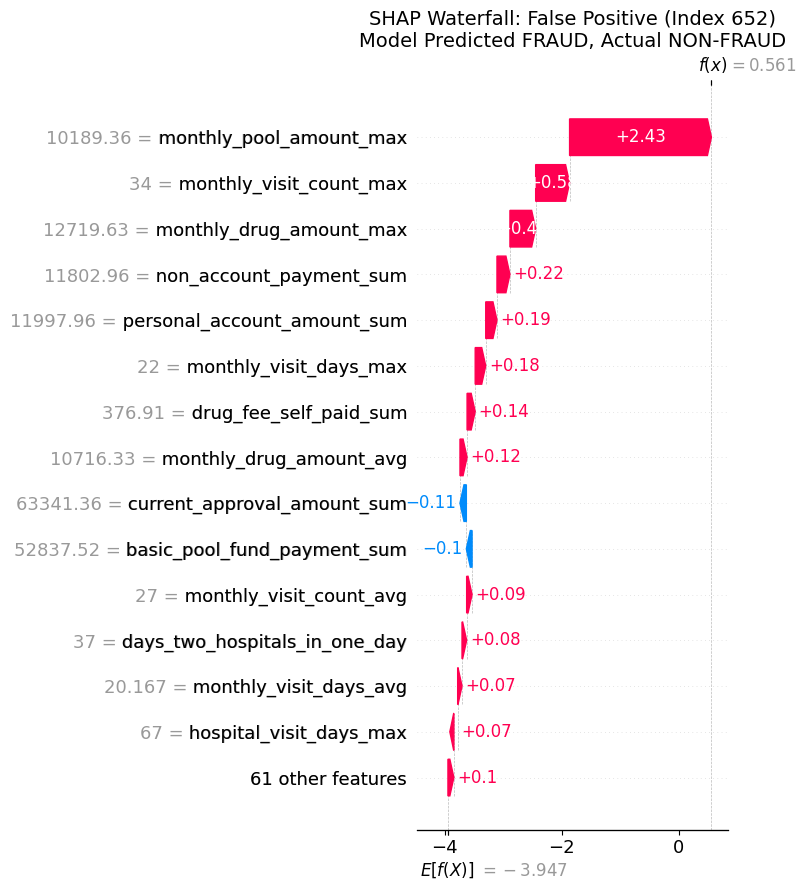

In [83]:
# ERROR ANALYSIS: FALSE POSITIVE INVESTIGATION 
print("ERROR ANALYSIS: FALSE POSITIVE (Innocent flagged as Fraud)")
print("="*55)

# 1. Find all False Positives in the test set
# y_test == 0 (Actual Non-Fraud) AND y_pred == 1 (Predicted Fraud)
fp_mask = (y_test == 0) & (y_pred == 1)
fp_indices = np.where(fp_mask)[0]

print(f"Total Non-Fraud Cases in Test Set: {len(np.where(y_test == 0)[0])}")
print(f"Innocents Falsely Flagged by Model (FP): {len(fp_indices)}")
print(f"Percentage of Non-Fraud Flagged: {len(fp_indices)/len(np.where(y_test == 0)[0])*100:.1f}%")

# 2. Select one specific False Positive to investigate
investigation_idx_fp = fp_indices[1]  # Pick the first innocent victim
print(f"\nInvestigating False Positive Sample Index: {investigation_idx_fp}")
print(f"Actual Label: {y_test[investigation_idx_fp]} (Non-Fraud)")
print(f"Model Prediction: {y_pred[investigation_idx_fp]} (Fraud)")

# 3. SHAP Waterfall plot for this false positive
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[investigation_idx_fp, :],
        base_values=explainer.expected_value,
        data=x_test[investigation_idx_fp, :],
        feature_names=feature_names
    ),
    max_display=15,  # Show top 15 features
    show=False
)
plt.title(f"SHAP Waterfall: False Positive (Index {investigation_idx_fp})\nModel Predicted FRAUD, Actual NON-FRAUD", fontsize=14)
plt.tight_layout()
plt.show()

AGGREGATE ERROR ANALYSIS: SYSTEMATIC MISTAKES
Total test samples: 3200
False Negatives (missed fraud): 93
False Positives (incorrect fraud): 14


FALSE NEGATIVES SUMMARY
----------------------------------------------------------------------
Count: 93
Mean |SHAP|: 0.0459
Std  |SHAP|: 0.1571
Top 10 features by average SHAP magnitude:
   1. monthly_pool_amount_max: mean=+0.6344, std=1.0107
   2. basic_pool_fund_payment_sum: mean=+0.1376, std=0.3193
   3. monthly_drug_amount_max: mean=+0.1249, std=0.2407
   4. current_approval_amount_sum: mean=+0.1211, std=0.2432
   5. pooled_payment_amount_sum: mean=+0.1017, std=0.1920
   6. herbal_medicine_sum: mean=+0.0789, std=0.1394
   7. hospital_drug_amount_max: mean=+0.0653, std=0.1576
   8. monthly_drug_amount_avg: mean=+0.0525, std=0.0718
   9. monthly_pool_amount_avg: mean=+0.0499, std=0.0590
  10. monthly_visit_days_avg: mean=+0.0449, std=0.1132

FALSE POSITIVES SUMMARY
----------------------------------------------------------------------
Coun

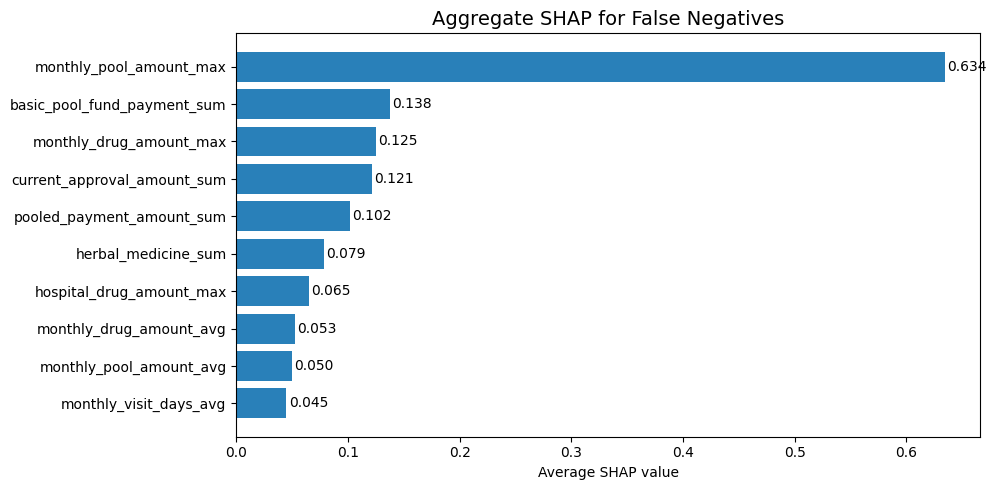

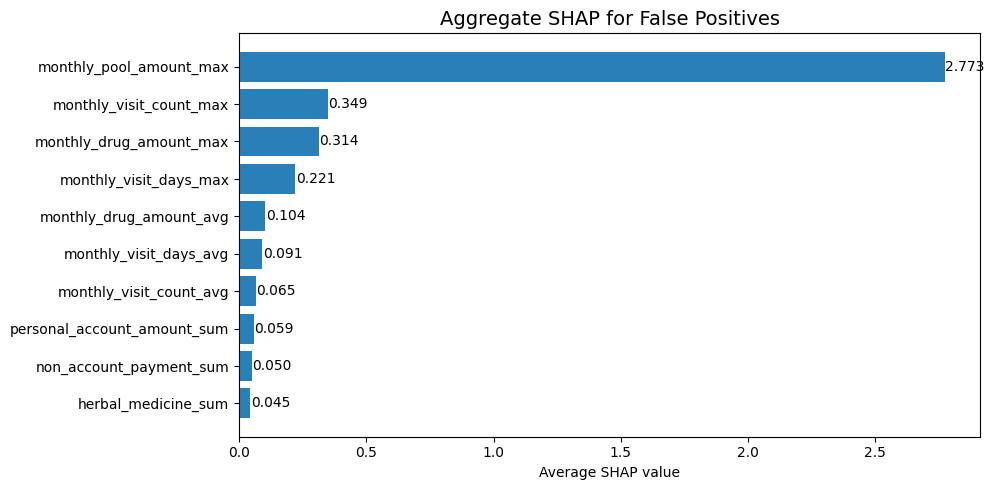


Interpretation guidance
- False Negative features with negative mean SHAP values are likely pushing true fraud cases toward a non-fraud prediction.
- False Positive features with positive mean SHAP values are likely driving innocent cases to a fraud prediction.
- Shared features suggest model instability around those predictors, while distinct feature sets indicate different blind spots.


In [84]:
print("AGGREGATE ERROR ANALYSIS: SYSTEMATIC MISTAKES")
print("=" * 70)

# Define error groups
fn_mask = (y_test == 1) & (y_pred == 0)
fp_mask = (y_test == 0) & (y_pred == 1)
fn_indices = np.where(fn_mask)[0]
fp_indices = np.where(fp_mask)[0]

print(f"Total test samples: {len(y_test)}")
print(f"False Negatives (missed fraud): {len(fn_indices)}")
print(f"False Positives (incorrect fraud): {len(fp_indices)}")
print()

if len(fn_indices) == 0 and len(fp_indices) == 0:
    print("No misclassified samples found. Nothing to aggregate.")
else:
    def summarize_errors(indices, label):
        data = shap_values[indices]
        mean_shap = np.mean(data, axis=0)
        std_shap = np.std(data, axis=0)
        abs_rank = np.argsort(np.abs(mean_shap))[::-1]
        top_idx = abs_rank[:10]

        print(f"\n{label} SUMMARY")
        print("-" * 70)
        print(f"Count: {len(indices)}")
        print(f"Mean |SHAP|: {np.mean(np.abs(data)):.4f}")
        print(f"Std  |SHAP|: {np.std(np.abs(data)):.4f}")
        print("Top 10 features by average SHAP magnitude:")
        for rank, idx in enumerate(top_idx, start=1):
            print(f"  {rank:2d}. {feature_names[idx]}: mean={mean_shap[idx]:+.4f}, std={std_shap[idx]:.4f}")
        return mean_shap, std_shap, top_idx

    fn_mean_shap, fn_std_shap, fn_top_idx = summarize_errors(fn_indices, "FALSE NEGATIVES")
    fp_mean_shap, fp_std_shap, fp_top_idx = summarize_errors(fp_indices, "FALSE POSITIVES")

    # Compare the error groups
    overlap = [idx for idx in fn_top_idx if idx in fp_top_idx]
    if overlap:
        print("\nShared top error features between FN and FP:")
        for idx in overlap:
            print(f"  - {feature_names[idx]}")
    else:
        print("\nNo direct overlap found among the top 10 error-driving features for FN and FP.")

    # Plot aggregate SHAP profiles for the top error features
    def plot_top_error_features(mean_shap, top_idx, title):
        feature_labels = [feature_names[i] for i in top_idx]
        values = mean_shap[top_idx]
        plt.figure(figsize=(10, 5))
        bars = plt.barh(feature_labels[::-1], values[::-1], color=['#c0392b' if v < 0 else '#2980b9' for v in values[::-1]])
        plt.title(title, fontsize=14)
        plt.xlabel('Average SHAP value')
        plt.tight_layout()
        for bar in bars:
            w = bar.get_width()
            plt.text(w + np.sign(w) * 0.002, bar.get_y() + bar.get_height() / 2,
                     f"{w:.3f}", va='center', fontsize=10)
        plt.show()

    if len(fn_indices) > 0:
        plot_top_error_features(fn_mean_shap, fn_top_idx, 'Aggregate SHAP for False Negatives')
    if len(fp_indices) > 0:
        plot_top_error_features(fp_mean_shap, fp_top_idx, 'Aggregate SHAP for False Positives')

    print("\nInterpretation guidance")
    print("- False Negative features with negative mean SHAP values are likely pushing true fraud cases toward a non-fraud prediction.")
    print("- False Positive features with positive mean SHAP values are likely driving innocent cases to a fraud prediction.")
    print("- Shared features suggest model instability around those predictors, while distinct feature sets indicate different blind spots.")

